# **Image Super-Resolution: Classical vs. Learned**

## **Objectives:**
1. Upscale a deliberately downsampled image with classical interpolation (bicubic, from notebook 6) vs. two small learned models (ESPCN, FSRCNN) via `cv2.dnn_superres`
2. Score every result with notebook 20's MSE/SSIM, plus PSNR
3. Find a real, non-obvious mismatch between *what looks sharper* and *what scores better numerically* — and understand why that gap is real, not a bug in the metric

> **Assets.** `assets/models/ESPCN_x4.pb` and `assets/models/FSRCNN_x4.pb` are official OpenCV GSoC 2019 contributions, linked directly from [opencv_contrib's own `dnn_superres` README](https://github.com/opencv/opencv_contrib/tree/4.x/modules/dnn_superres) — [fannymonori/TF-ESPCN](https://github.com/fannymonori/TF-ESPCN) and [Saafke/FSRCNN_Tensorflow](https://github.com/Saafke/FSRCNN_Tensorflow), both Apache 2.0. Genuinely tiny (~100KB and ~42KB) — no size trade-off to flag here, unlike a couple of the other DNN notebooks in this repo.
>
> `cv2.dnn_superres` lives in the `opencv-contrib` package, not the plain `opencv-python-headless` this repo used to pin — `requirements.txt` was switched to `opencv-contrib-python-headless==4.10.0.84` for this notebook (same exact underlying version, confirmed a drop-in swap by re-executing every other notebook against it unchanged).

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## **Setting up a fair test**

Take a real, sharp photo, deliberately shrink it 4x (throwing away real detail on purpose), then try to get that detail back three different ways. Having the original around means every result can be checked against genuine ground truth, not just judged by eye.

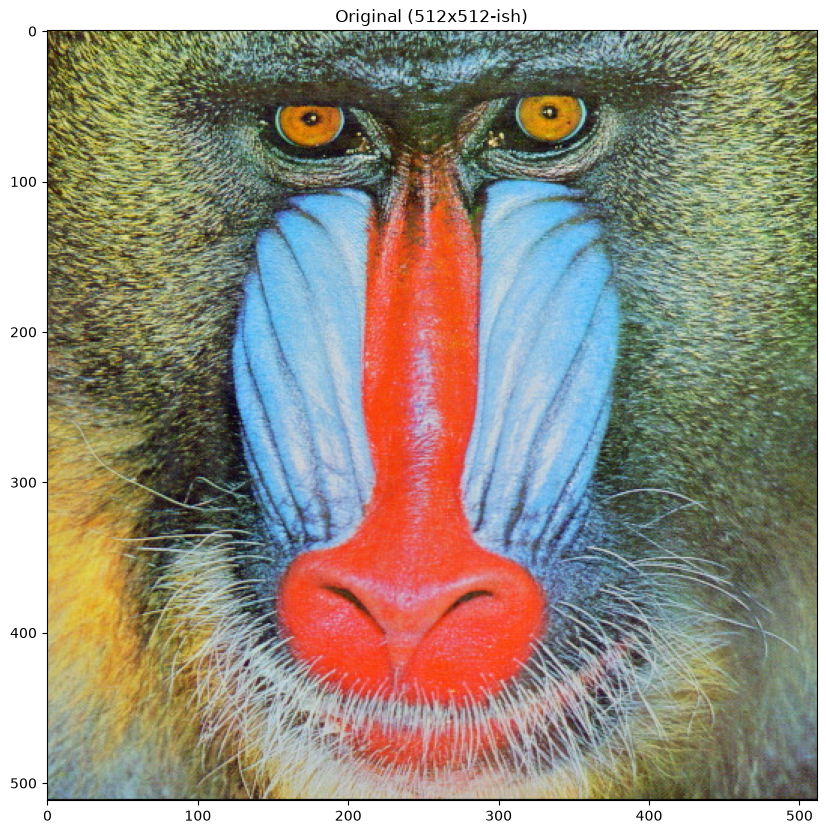

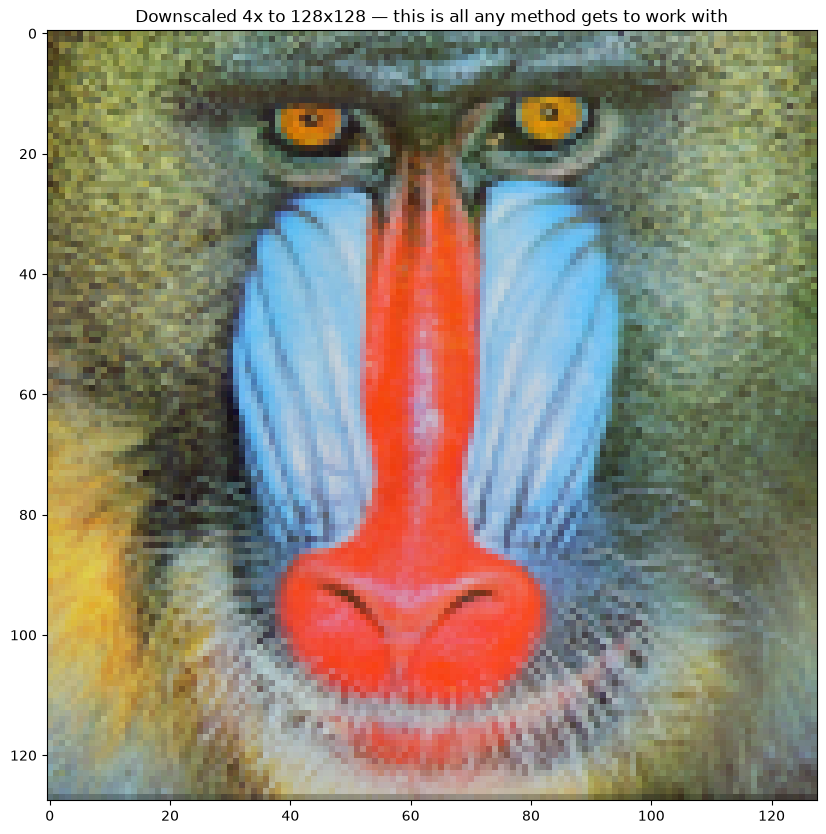

In [2]:
original = cv2.imread('assets/images/baboon.jpg')
h, w = original.shape[:2]
h, w = h - h % 4, w - w % 4   # crop to a multiple of 4 so upscaling lands back exactly
original = original[:h, :w]
small = cv2.resize(original, (w // 4, h // 4), interpolation=cv2.INTER_AREA)

imshow('Original (512x512-ish)', original)
imshow(f'Downscaled 4x to {small.shape[1]}x{small.shape[0]} — this is all any method gets to work with', small)

## **Three ways back up to full size**

- **Bicubic** (`cv2.INTER_CUBIC`, notebook 6) — a fixed mathematical formula: each new pixel is a weighted blend of the 16 nearest source pixels. No knowledge of what a photo "should" look like — pure interpolation.
- **ESPCN** — a tiny CNN that learns the upscaling filters from data instead of using a fixed formula, with the clever trick of running the expensive convolutions at the *low* resolution and only expanding to full size in the last "sub-pixel convolution" layer (fast: its whole selling point).
- **FSRCNN** — a different small CNN architecture, similar goal, comparable speed, trained separately.

In [3]:
sr_espcn = cv2.dnn_superres.DnnSuperResImpl_create()
sr_espcn.readModel('assets/models/ESPCN_x4.pb')
sr_espcn.setModel('espcn', 4)

sr_fsrcnn = cv2.dnn_superres.DnnSuperResImpl_create()
sr_fsrcnn.readModel('assets/models/FSRCNN_x4.pb')
sr_fsrcnn.setModel('fsrcnn', 4)

bicubic = cv2.resize(small, (w, h), interpolation=cv2.INTER_CUBIC)
espcn = sr_espcn.upsample(small)
fsrcnn = sr_fsrcnn.upsample(small)

print('All three results:', bicubic.shape, espcn.shape, fsrcnn.shape)

All three results: (512, 512, 3) (512, 512, 3) (512, 512, 3)


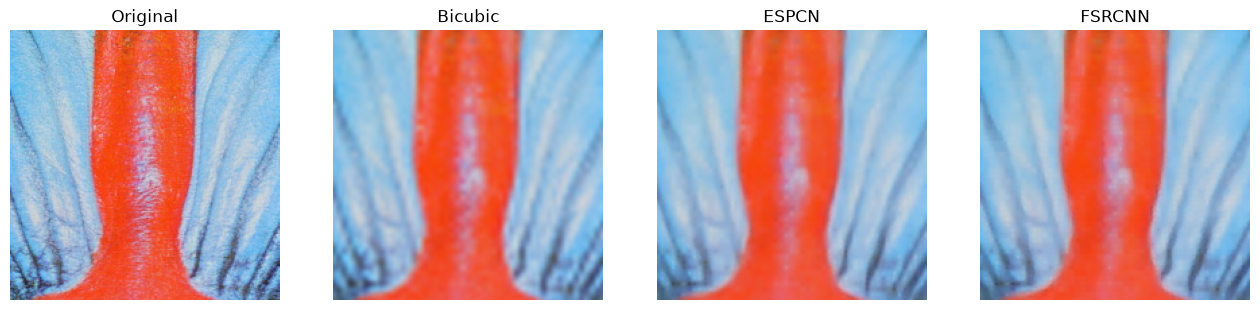

In [4]:
y0, y1, x0, x1 = 150, 350, 150, 350  # a detail-rich crop: the fur texture
crops = [original[y0:y1, x0:x1], bicubic[y0:y1, x0:x1], espcn[y0:y1, x0:x1], fsrcnn[y0:y1, x0:x1]]
titles = ['Original', 'Bicubic', 'ESPCN', 'FSRCNN']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, crop, title in zip(axes, crops, titles):
    ax.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis('off')
plt.show()

## **Scoring it — reusing notebook 20's tools, plus PSNR**

MSE and SSIM are exactly the pair notebook 20 used to compare two images objectively instead of by eye. PSNR (Peak Signal-to-Noise Ratio, in dB — higher is better) is the standard third metric for this exact task: restoring a degraded image and checking it against the original.

In [5]:
from skimage.metrics import structural_similarity, peak_signal_noise_ratio

def mse(image1, image2):
    error = np.sum((image1.astype('float') - image2.astype('float')) ** 2)
    return error / float(image1.shape[0] * image1.shape[1])

def score(name, result):
    g1 = cv2.cvtColor(original, cv2.COLOR_BGR2GRAY)
    g2 = cv2.cvtColor(result, cv2.COLOR_BGR2GRAY)
    print(f'{name:8s}  MSE={mse(g1, g2):8.2f}   '
          f'SSIM={structural_similarity(g1, g2):.4f}   '
          f'PSNR={peak_signal_noise_ratio(original, result):.2f} dB')

score('Bicubic', bicubic)
score('ESPCN', espcn)
score('FSRCNN', fsrcnn)

Bicubic   MSE=  520.84   SSIM=0.4807   PSNR=20.80 dB
ESPCN     MSE=  540.63   SSIM=0.4456   PSNR=20.62 dB
FSRCNN    MSE=  537.98   SSIM=0.4471   PSNR=20.64 dB


## **The mismatch, and why it's real**

Look closely at the numbers above against the crop image a few cells up. **Bicubic — the method with no learning at all — tends to score *as well or fractionally better* on MSE/SSIM/PSNR than ESPCN and FSRCNN, while visibly looking blurrier and less detailed.** That's not a mistake in either the metrics or the models. All three of these metrics are *pixel-difference* measures: they penalize *any* deviation from the original equally, in every direction. Bicubic plays it safe — it produces a smooth average that's rarely far wrong anywhere, which pixel-difference metrics reward. A learned model adds genuine texture and sharp edges *because it learned what fur/foliage/edges statistically look like* — but guessing confidently means guessing wrong sometimes too, and every wrong guess is penalized just as hard as bicubic's safe blur, even though the *overall image* looks more correct to a human.

This exact gap — sharper-looking results scoring the same or worse on PSNR/SSIM — is well known in the super-resolution research literature (it's a large part of why perceptual and adversarial losses, e.g. in SRGAN, were introduced instead of optimizing PSNR directly). The honest takeaway isn't "ESPCN/FSRCNN are worse than doing nothing" — it's that **no single number tells the whole story, and a metric measuring the right *kind* of error matters as much as the number itself.**

### One or two things to try next

- Try `x2` instead of `x4` scale for both models (`assets/models/ESPCN_x4.pb` has x2/x3 siblings at the same source repo) — the sharper-but-scores-worse gap should shrink, since there's less missing detail to guess at.
- Swap `assets/images/baboon.jpg` for something smoother and less textured (`assets/images/sudoku.png`) — predict, then check, whether the PSNR/SSIM gap between bicubic and the learned models narrows or reverses on a low-texture image.
- Add EDSR (`opencv_contrib`'s own README links a ~38MB quantized model) to the comparison — much slower, but the accuracy leader on this exact benchmark; see whether it actually wins on both the eye test and the numbers.